In [7]:
pip install sentence_transformers

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
import hdbscan
import umap
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

In [9]:
df = pd.read_excel('Диалоги пилотов.xlsx')

Выполним грубую разметку на штатные и экстренные ситуации

In [10]:
# список слов-маркеров
emergency_markers = [
    'emergency', 'mayday', 'pan pan', 'failed', 'failure', 
    'fire', 'stop immediately', 'going around', 'belly landing', 
    'structural failure', 'engine out', 'on fire', 'warning light',
    'priority landing', 'emergency descent', 'evacuation'
]

def mark_risk(text):
    text = str(text).lower()
    for word in emergency_markers:
        if word in text:
            return 1
    return 0

# Применяем функцию ко всем диалогам
df['Label'] = df['Dialogs Pilot/Controller'].apply(mark_risk)

# Сохраняем размеченный файл
df.to_excel('Диалоги_готовые_для_ML.xlsx', index=False)
print(df['Label'].value_counts())

Label
0    25
1    15
Name: count, dtype: int64


Попробуем так же сделать груюу. классификацию

In [11]:
def classify_problem(text):
    text = str(text).lower()
    if 'engine' in text or 'bird' in text or 'surge' in text:
        return 'Engine'
    elif 'ice' in text or 'turbulence' in text or 'wind shear' in text:
        return 'Weather'
    elif 'position' in text or 'radar' in text or 'vector' in text:
        return 'Navigation'
    elif 'hydraulic' in text or 'gear' in text or 'brake' in text:
        return 'Mechanical'
    else:
        return 'Other'

In [12]:
df['Class'] = df['Dialogs Pilot/Controller'].apply(classify_problem)

Как мы можем заметить, в результате выполнения данного скрипта получился очень урезанный список экстренных ситуаций. Это отражает поверхностность такого подхода. Попробуем использовать более сложные механизмы

In [13]:
def mark_risk_advanced(text):
    text = str(text).lower()
    
    # проверка по основным сигналам
    critical_words = ['emergency', 'mayday', 'pan pan', 'fire', 'on fire', 
                      'stop immediately', 'belly landing', 'evacuation']
    for word in critical_words:
        if word in text:
            return 1
    
    # проверка на фраз с отказом
    failure_patterns = [
        r'engine (failed|failure|out)', 
        r'hydraulic (pressure dropping|failure)',
        r'gear cannot be deployed',
        r'structural failure',
        r'warning light (is on|keeps coming on)',
        r'transponder (inoperative|appears inoperative)',
        r'alternator malfunctioned',
        r'electrical problem'
    ]
    for pattern in failure_patterns:
        if re.search(pattern, text):
            return 1
    
    # запросы на изменение плана
    request_patterns = [
        r'request (priority landing|emergency descent|radar vectors|return)',
        r'need to (descend immediately|dump fuel)',
        r'we have a problem',
        r'not sure of our position'
    ]
    for pattern in request_patterns:
        if re.search(pattern, text):
            return 1
    
    # метеоопасности 
    weather_patterns = [
        r'(severe|heavy) (icing|turbulence)',
        r'ice build up',
        r'wind shear',
        r'chunks of ice'
    ]
    for pattern in weather_patterns:
        if re.search(pattern, text):
            return 1
    
    return 0

In [14]:
# применение скрипта
df['Label'] = df['Dialogs Pilot/Controller'].apply(mark_risk_advanced)
print(df['Label'].value_counts())


Label
0    21
1    19
Name: count, dtype: int64


В итоге данный способ показал результат хуже предыдущего, из чего можно сделать вывод, что для начала стоит начать с ручной разметки. Отобразим результаты выполнения скриптов и ручной разметки на графике

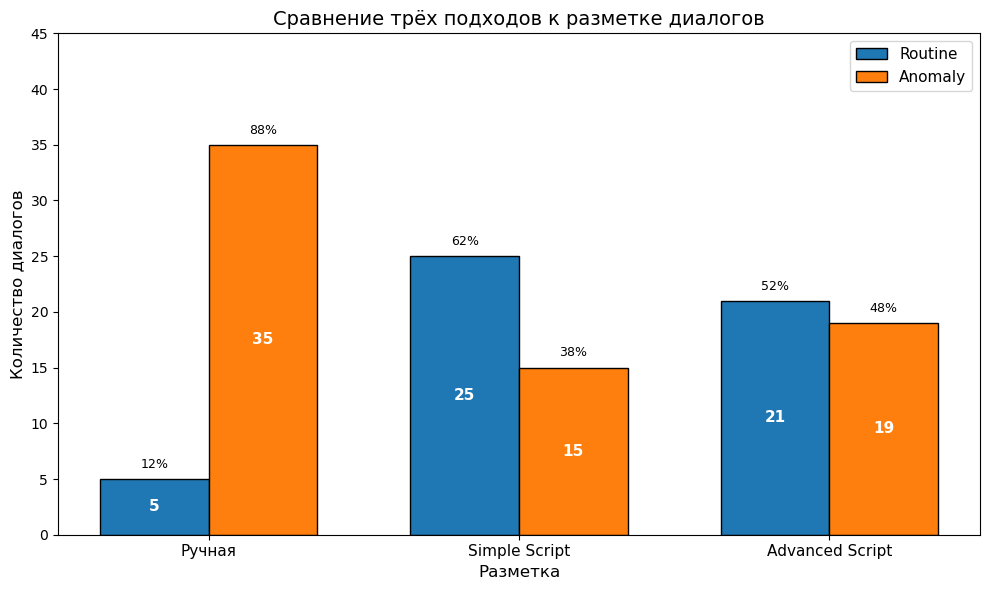

In [15]:
methods = ['Ручная', 'Simple Script', 'Advanced Script']
routine = [5, 25, 21]
anomaly = [35, 15, 19]
total = [40, 40, 40]

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, routine, width, label='Routine', edgecolor='black')
bars2 = ax.bar(x + width/2, anomaly, width, label='Anomaly', edgecolor='black')

ax.set_xlabel('Разметка', fontsize=12)
ax.set_ylabel('Количество диалогов', fontsize=12)
ax.set_title('Сравнение трёх подходов к разметке диалогов', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.legend(loc='upper right', fontsize=11)

ax.bar_label(bars1, label_type='center', fontsize=11, color='white', fontweight='bold')
ax.bar_label(bars2, label_type='center', fontsize=11, color='white', fontweight='bold')

for i, (r, a) in enumerate(zip(routine, anomaly)):
    total_i = r + a
    ax.text(i - width/2, r + 1, f'{r/total_i*100:.0f}%', ha='center', fontsize=9)
    ax.text(i + width/2, a + 1, f'{a/total_i*100:.0f}%', ha='center', fontsize=9)

ax.set_ylim(0, 45)

plt.tight_layout()
plt.savefig('comparison_labeling_methods.png', dpi=300, bbox_inches='tight')
plt.show()

Так как базисные скрипты показывают плохие результаты, используем методы кластеризации

In [16]:
texts = df['Dialogs Pilot/Controller'].astype(str).tolist()

Генерируем эмбеддинги

In [17]:
model = SentenceTransformer('all-MiniLM-L6-v2')

#генерируем эмбеддинги для всех диалогов
embeddings = model.encode(texts, show_progress_bar=True)

print('Размерность эмбеддингов:', embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Размерность эмбеддингов: (40, 384)


Кластеризируем с помощью модели

In [18]:
#настраиваем HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2, #минимальное количество точек в кластере
    min_samples=1, #чувствительность к шуму
    metric='euclidean', 
    cluster_selection_epsilon=0.5,  #объединяет близкие кластеры
    prediction_data=True
)

#применяем кластеризацию
cluster_labels = clusterer.fit_predict(embeddings)

#добавляем метки кластеров в датафрейм
df['Cluster'] = cluster_labels

#количество кластеров без шума
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print('Количество кластеров: ', n_clusters)
print('Количество шумовых точек: ', n_noise)
print('Распределение по кластерам:')
print(df['Cluster'].value_counts().sort_index())

Количество кластеров:  10
Количество шумовых точек:  11
Распределение по кластерам:
Cluster
-1    11
 0     2
 1     4
 2     2
 3     2
 4     3
 5     5
 6     4
 7     3
 8     2
 9     2
Name: count, dtype: int64


-1 -- кластер шума

Визуализируем полученные результаты

c:\Users\464\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


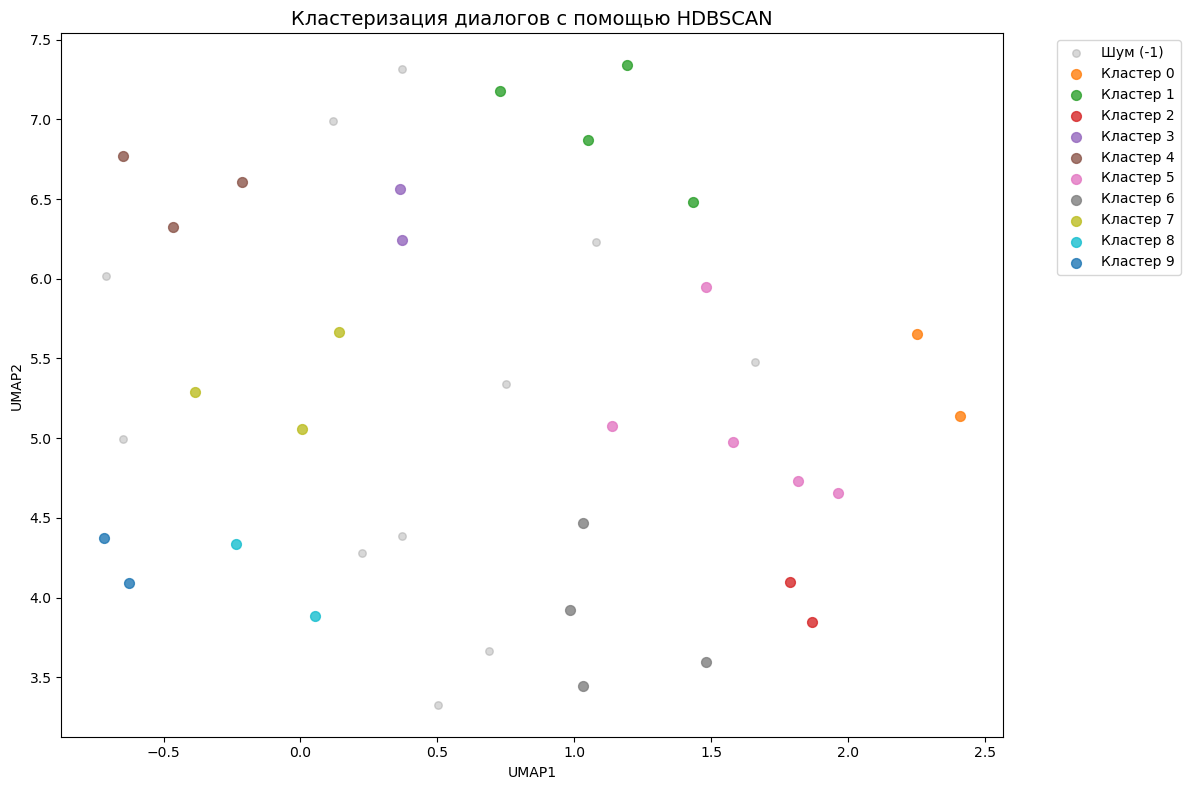

In [19]:
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_embeddings = umap_reducer.fit_transform(embeddings)

df_umap = pd.DataFrame(umap_embeddings, columns=['UMAP1', 'UMAP2'])
df_umap['Cluster'] = cluster_labels
df_umap['Label'] = df['Label']

plt.figure(figsize=(12, 8))

unique_clusters = sorted(df_umap['Cluster'].unique())
colors = sns.color_palette('tab10', n_colors=len(unique_clusters))

for i, cluster in enumerate(unique_clusters):
    mask = df_umap['Cluster'] == cluster
    if cluster == -1: #для шума используем серый цвет
        plt.scatter(df_umap.loc[mask, 'UMAP1'], df_umap.loc[mask, 'UMAP2'], 
                    color='gray', alpha=0.3, s=30, label=f'Шум (-1)')
    else:
        plt.scatter(df_umap.loc[mask, 'UMAP1'], df_umap.loc[mask, 'UMAP2'], 
                    color=colors[i % len(colors)], alpha=0.8, s=50, label=f'Кластер {cluster}')

plt.title('Кластеризация диалогов с помощью HDBSCAN', fontsize=14)
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('clusters_hdbscan.png', dpi=300, bbox_inches='tight')
plt.show()

Точки выглядят довльно сильно разброшенными относительно друг друга, тем не менее, стоит выделить ключевые слова, чтобы понять, как механизм определил кластеры

In [20]:
def get_top_words_per_cluster(texts, labels, n_words=5):
    #создаём список текстов для каждого кластера
    cluster_texts = {}
    for label, text in zip(labels, texts):
        if label not in cluster_texts:
            cluster_texts[label] = []
        cluster_texts[label].append(text)
    
    #для каждого кластера вычисляем TF-IDF и берём топ-слова
    top_words = {}
    for label, cluster_text_list in cluster_texts.items():
        #объединяем все тексты кластера в один документ
        combined_text = ' '.join(cluster_text_list)
        #используем TfidfVectorizer для получения важных слов
        vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
        tfidf_matrix = vectorizer.fit_transform([combined_text])
        feature_names = vectorizer.get_feature_names_out()
        #получаем значения TF-IDF
        tfidf_values = tfidf_matrix.toarray()[0]
        #сортируем слова по убыванию TF-IDF
        sorted_indices = tfidf_values.argsort()[::-1][:n_words]
        top_words[label] = [feature_names[idx] for idx in sorted_indices if tfidf_values[idx] > 0]
    
    return top_words

#получаем топ-5 слов для каждого кластера
top_words = get_top_words_per_cluster(texts, cluster_labels, n_words=5)

#выводим для каждого кластера
print("\nКлючевые слова по кластерам:")
for cluster, words in top_words.items():
    if cluster == -1:
        print(f"Шум (-1): {words}")
    else:
        print(f"Кластер {cluster}: {words}")


Ключевые слова по кластерам:
Кластер 6: ['pilot', 'control', 'traffic', '222', 'air']
Кластер 5: ['pilot', 'fl', 'pr', 'controller', '623']
Кластер 1: ['pilot', 'newstar', '819', 'tower', '829']
Кластер 2: ['pilot', 'radar', 'controller', '219', 'heading']
Кластер 3: ['tower', 'delta', '907', 'pilot', '726']
Кластер 4: ['runway', '847', 'pilot', 'control', 'taxi']
Шум (-1): ['pilot', 'controller', 'roger', 'runway', 'approach']
Кластер 8: ['pilot', '908', 'approach', 'runway', 'descend']
Кластер 9: ['approach', 'air', 'ils', 'pilot', 'controller']
Кластер 7: ['orient', 'pilot', '718', 'atc', 'runway']
Кластер 0: ['tower', 'pilot', '690', '886', 'jack']


По полученным данным можем заметить, что метки пилота и диспетчера в диалоге сильно сбивают модель. Удалим слова Pilot и Controller, также увеличим минимальное количество диалогов в кластере и выделим именно уникальные слова для каждого из кластеров.

Так же исключим стоп-слова с помощью библиотеки skilearn

In [21]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
aviation_stopwords = ['pilot', 'controller', 'tower', 'roger', 'wilco', 'affirm', 'negative',
    'over', 'out', 'break', 'standby', 'go ahead', 'say again',
    'flight', 'level', 'fl', 'feet', 'ft', 'heading', 'course',
    'runway', 'rwy', 'taxi', 'hold', 'contact', 'frequency',
    'qnh', 'qfe', 'hpa', 'squawk', 'ident', 'radar', 'vector',
    'good', 'morning', 'afternoon', 'evening', 'day', 'number']
all_stopwords = set(aviation_stopwords).union(ENGLISH_STOP_WORDS)

In [22]:
def clean_text(text):
    text = str(text).lower()
    #удаляем номера рейсов
    text = re.sub(r'\b[a-z]+ \d+\b', '', text)
    text = re.sub(r'\b[a-z]+[0-9]+\b', '', text)
    #удаляем цифры и знаки препинания
    text = re.sub(r'[^a-z\s]', '', text)
    #удаляем стоп-слова
    words = text.split()
    words = [w for w in words if w not in all_stopwords and len(w) > 2]
    return ' '.join(words)

Теперь применим очистку

In [23]:
df = pd.read_excel('Диалоги пилотов без слов.xlsx')

In [24]:
df.head()

,Number of dialog,Dialogs Pilot/Controller,Type
0,1,"“Approach good afternoon, this is Good Ai...",ordinary
1,2,"Jetwind 207, descend to FL 120, report pa...",Abnormal
2,3,"Cranby Tower, Newstar 819, left engine fai...",Abnormal
3,4,"Gisborne Radar, Sunair 219\n Sunair 21...",Abnormal
4,5,"Tower Delta 907, line up and wait, vehicle c...",Abnormal


In [25]:
df['Clean_Text'] = df['Dialogs Pilot/Controller'].apply(clean_text)
texts_clean = df['Clean_Text'].tolist()

In [26]:
embeddings_clean = model.encode(texts_clean, show_progress_bar=True)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Проведем кластризацию уже с новыми параметрами

In [27]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,       
    min_samples=1,
    metric='euclidean',
    cluster_selection_epsilon=0.3,
    prediction_data=True
)
cluster_labels_clean = clusterer.fit_predict(embeddings_clean)
df['Cluster_clean'] = cluster_labels_clean

n_clusters_clean = len(set(cluster_labels_clean)) - (1 if -1 in cluster_labels_clean else 0)
n_noise_clean = list(cluster_labels_clean).count(-1)
print('Кластеров:', n_clusters_clean, 'шум: ', n_noise_clean)

Кластеров: 5 шум:  10


In [28]:
from collections import defaultdict

def c_tf_idf(documents, labels):
    #объединяем тексты по кластерам
    cluster_texts = defaultdict(str)
    for doc, label in zip(documents, labels):
        cluster_texts[label] += doc + ' '
    
    #создаём список документов кластеров
    cluster_docs = [cluster_texts[label] for label in sorted(cluster_texts.keys()) if label != -1]
    cluster_labels = [label for label in sorted(cluster_texts.keys()) if label != -1]
    
    #TF-IDF векторизатор
    vectorizer = TfidfVectorizer(stop_words='english', max_features=100)
    tfidf_matrix = vectorizer.fit_transform(cluster_docs)
    feature_names = vectorizer.get_feature_names_out()
    
    top_words_per_cluster = {}
    for i, label in enumerate(cluster_labels):
        tfidf_row = tfidf_matrix[i].toarray()[0]
        top_indices = tfidf_row.argsort()[-5:][::-1]
        top_words = [feature_names[idx] for idx in top_indices if tfidf_row[idx] > 0]
        top_words_per_cluster[label] = top_words
    
    return top_words_per_cluster

In [29]:
top_words_c = c_tf_idf(texts_clean, cluster_labels_clean)
print('Ключевые слова по кластерам c-TF-IDF:')
for cluster, words in top_words_c.items():
    print(f"Кластер {cluster}: {words}")

Ключевые слова по кластерам c-TF-IDF:
Кластер 0: ['gears', 'weve', 'loso', 'cala', 'extension']
Кластер 1: ['atc', 'pan', 'control', 'reaching', 'altitude']
Кластер 2: ['stop', 'immediately', 'takeoff', 'departure', 'vacate']
Кластер 3: ['approach', 'traffic', 'control', 'ils', 'atc']
Кластер 4: ['fly', 'direct', 'pim', 'request', 'problem']


Кластеры все равно получаются довольно размытыми. Попробуем пока отвлечься от разделения на конкретные темы и выделим два кластера: экстренные и обыденные ситуации